## 01 Import Data

### 01-1 Setup Config

In [1]:
from dotenv import load_dotenv
from utils import init_mlflow
import os
import json
load_dotenv()
POSTGRES_URI = os.getenv('POSTGRES_URI')
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

# Set the stock code you want to analyze
STOCK_CODE = 2330

map_dict_path = '/app/data/column_mapping.json'
init_mlflow()
with open(map_dict_path, 'r', encoding='utf-8') as f:
    map_dict = json.load(f)
# '6770', '2337', '2344', '2303', '2408', '2515', '5521', '2542', '1316', '2442', '2485', '6285', '2455', '2412', '4977', '2367', '2313', '3037', '4958', '2327'

In [3]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict
import math
import time
import mlflow

%matplotlib inline

START_DATE = "2020-01-01"
END_DATE = time.strftime("%Y-%m-%d")

stock_dict_path = '/app/data/top5_stocks_by_category.json'
with open(stock_dict_path, 'r', encoding='utf-8') as f:
    stock_dict = json.load(f)

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))
tqdm.pandas()
mlflow.set_experiment("LSTM_Test")
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

### 01-2 Load Data

In [11]:
[int(x) for x in stock_dict['半導體業']]

[2330, 2408, 2344, 6770, 2337]

In [22]:
def get_stock_data(stock_code, start_date: str, end_date: str, return_all=False):
    # Fetch data from PostgreSQL database
    table_name = f'daily_info_{stock_code}'
    query = f"""
    SELECT *
    FROM {table_name}
    WHERE stock_code_id = '{stock_code}'
      AND date BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY date ASC;
    """
    df = pd.read_sql(query, POSTGRES_URI)

    # Rename columns using the mapping dictionary
    df.rename(columns=map_dict, inplace=True)
    return df

def get_stock_data_by_category(category, start_date: str, end_date: str):
    """
    category: 'ETF', '建材營造', '電子零組件業', '半導體業', '通信網路業'
    """
    stock_codes = stock_dict.get(category, [])
    stock_codes = [int(code) for code in stock_codes]
    all_data = []
    for code in stock_codes:
        try:
            df = get_stock_data(code, start_date, end_date)
            all_data.append(df)
        except Exception as e:
            print(f"Error fetching data for stock code {code}: {e}")
    final_df = pd.concat(all_data, ignore_index=True)
    # final_df = final_df.sort_values(by=['date', 'stock_code_id']).reset_index(drop=True)
    return final_df

df = get_stock_data_by_category("半導體業", START_DATE, END_DATE)
df.head()

Error fetching data for stock code 6770: (psycopg.errors.UndefinedTable) relation "daily_info_6770" does not exist
LINE 3:     FROM daily_info_6770
                 ^
[SQL: 
    SELECT *
    FROM daily_info_6770
    WHERE stock_code_id = '6770'
      AND date BETWEEN '2020-01-01' AND '2026-04-21'
    ORDER BY date ASC;
    ]
(Background on this error at: https://sqlalche.me/e/20/f405)


,date,capacity,turnover,high,low,close,change,transaction_volume,stock_code_id,open
0,2020-01-02 01:00:00,33282120.0,1.122417e+10,339.0,332.5,339.0,8.0,17160,2330,332.5
1,2020-01-03 01:00:00,42023268.0,1.429565e+10,345.0,335.5,339.5,0.5,20545,2330,344.0
2,2020-01-06 01:00:00,45677057.0,1.521053e+10,334.5,332.0,332.0,-7.5,22944,2330,333.0
3,2020-01-07 01:00:00,51746181.0,1.705328e+10,333.0,326.5,329.5,-2.5,22362,2330,332.5
4,2020-01-08 01:00:00,37913748.0,1.248441e+10,333.0,325.0,329.5,0.0,18228,2330,325.0


In [19]:
# Fill null values in 'change' using the values from 'change_new' (today's close - yesterday's close)
# df['change_new'] = df['close']-df['close'].shift(1)
# df['change'] = df['change'].fillna(df['change_new'])
# df = df.drop(columns=['change_new'])
df.isnull().sum()

date                  0
capacity              0
turnover              0
high                  0
low                   0
close                 0
change                0
transaction_volume    0
stock_code_id         0
open                  0
dtype: int64

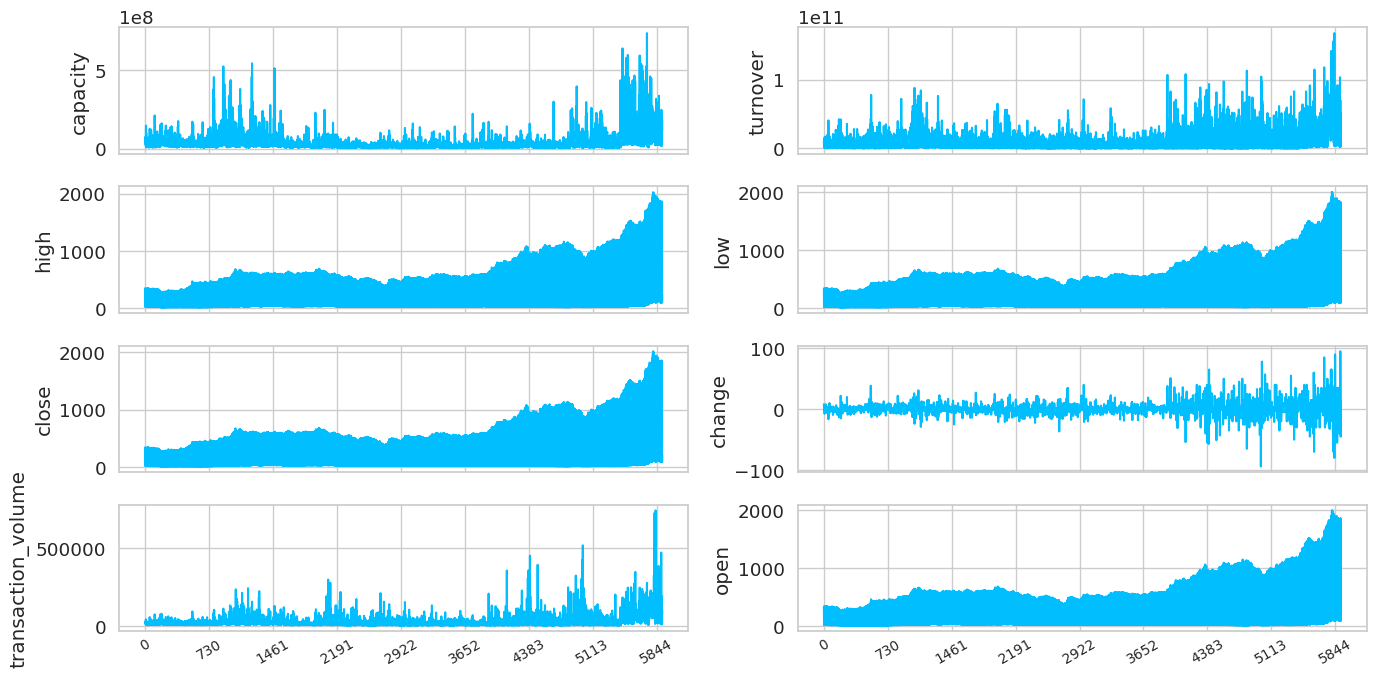

In [20]:
def data_plot(df):
    # Plot line charts
    df_plot = df.drop(columns=['stock_code_id', 'date'])

    ncols = 2
    nrows = int(round(df_plot.shape[1] / ncols, 0))

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
    for i, ax in enumerate(fig.axes):
        sns.lineplot(data=df_plot.iloc[:, i], ax=ax)
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.tight_layout()
    plt.show()

data_plot(df)

### 01-3 Feature Engineering

In [34]:
# Multi-stock feature engineering (4 stocks in the same industry)
train_ratio = 0.9
test_ratio = 1 - train_ratio

# 1) Pick 4 stock codes and align by date
selected_stocks = sorted(df['stock_code_id'].unique())[:4]
print(f"Selected stock codes: {selected_stocks}")

# Keep only required rows/columns and normalize date granularity
df_sub = df[df['stock_code_id'].isin(selected_stocks)].copy()
df_sub['date'] = pd.to_datetime(df_sub['date']).dt.normalize()

# If same stock has duplicate rows on the same date, keep one value by aggregation
dup_cnt = int(df_sub.duplicated(subset=['date', 'stock_code_id']).sum())
if dup_cnt > 0:
    print(f"Found {dup_cnt} duplicate (date, stock_code_id) rows. Aggregating by mean close.")

close_daily = (
    df_sub.groupby(['date', 'stock_code_id'], as_index=False)['close']
    .mean()
    .sort_values(['date', 'stock_code_id'])
)

# Use pivot_table to safely reshape even if duplicates exist
close_wide = (
    close_daily.pivot_table(
        index='date',
        columns='stock_code_id',
        values='close',
        aggfunc='mean',
    )
    .sort_index()
    .ffill()
    .bfill()
)
close_wide.columns = [f"close_{int(code)}" for code in close_wide.columns]

# 2) Build cross-stock features
ret_wide = close_wide.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
ret_wide.columns = [f"ret_{col.split('_')[1]}" for col in close_wide.columns]

market_mean_close = close_wide.mean(axis=1).to_frame('market_mean_close')
market_mean_ret = ret_wide.mean(axis=1).to_frame('market_mean_ret')

rel_close = close_wide.sub(close_wide.mean(axis=1), axis=0)
rel_close.columns = [f"rel_{col}" for col in close_wide.columns]

feature_df = pd.concat(
    [close_wide, ret_wide, market_mean_close, market_mean_ret, rel_close],
    axis=1,
).dropna()

target_cols = close_wide.columns.tolist()
feature_cols = feature_df.columns.tolist()

# 3) Time-based split (no shuffle): train:test = 9:1
n_total = len(feature_df)
n_train = int(n_total * train_ratio)

df_train = feature_df.iloc[:n_train].copy()
df_test = feature_df.iloc[n_train:].copy()

df_X_train = df_train[feature_cols]
df_X_test = df_test[feature_cols]

df_y_train = df_train[target_cols]
df_y_test = df_test[target_cols]

print(f"Train set: {len(df_X_train)} samples")
print(f"Test set: {len(df_X_test)} samples")
print(f"Target columns: {target_cols}")

Selected stock codes: ['2330', '2337', '2344', '2408']
Found 5 duplicate (date, stock_code_id) rows. Aggregating by mean close.
Train set: 1328 samples
Test set: 148 samples
Target columns: ['close_2330', 'close_2337', 'close_2344', 'close_2408']


In [35]:
# Scale features and multi-target labels
x_scaler = MinMaxScaler(feature_range=(0, 1))
df_X_train_scaled = x_scaler.fit_transform(df_X_train.values)
df_X_test_scaled = x_scaler.transform(df_X_test.values)

y_scaler = MinMaxScaler(feature_range=(0, 1))
df_y_train_scaled = y_scaler.fit_transform(df_y_train.values)
df_y_test_scaled = y_scaler.transform(df_y_test.values)

# Per-stock price scaling factor for RMSE conversion
price_scales = y_scaler.data_max_ - y_scaler.data_min_
stock_codes = [int(col.split('_')[1]) for col in target_cols]

print("X_train_scaled shape:", df_X_train_scaled.shape)
print("y_train_scaled shape:", df_y_train_scaled.shape)
print("Price scales:", dict(zip(stock_codes, np.round(price_scales, 4))))

X_train_scaled shape: (1328, 14)
y_train_scaled shape: (1328, 4)
Price scales: {2330: np.float64(928.0), 2337: np.float64(31.55), 2344: np.float64(28.54), 2408: np.float64(77.1)}


## 02 Model Training

### 02-1 Create Sequences and Labels for training and testing

In [42]:
# Create sequences for multi-stock forecasting
sequence_length = 7  # Number of time steps to look back

def create_sequences(X_array, y_array, seq_len):
    X_out, y_out = [], []
    for i in range(len(X_array) - seq_len):
        X_out.append(X_array[i:i + seq_len])
        y_out.append(y_array[i + seq_len])
    return np.array(X_out), np.array(y_out)

X_train_np, y_train_np = create_sequences(df_X_train_scaled, df_y_train_scaled, sequence_length)
X_test_np, y_test_np = create_sequences(df_X_test_scaled, df_y_test_scaled, sequence_length)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

X_train shape: torch.Size([1321, 7, 14]) y_train shape: torch.Size([1321, 4])
X_test shape: torch.Size([141, 7, 14]) y_test shape: torch.Size([141, 4])


In [43]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])  # Use the output of the last time step
        return out
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  

Using device: cuda


In [44]:
# Setup model parameters for multi-output forecasting
params = {
    'input_size': X_train.shape[2],
    'hidden_size': 32,
    'num_layers': 3,
    'output_size': y_train.shape[1],  # 4 stocks
    'dropout': 0.3,
}

model = LSTMModel(
    params['input_size'],
    params['hidden_size'],
    params['num_layers'],
    params['output_size'],
    params['dropout'],
).to(device)
loss_fn = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_epochs = 100
train_hist = []
train_rmse_price_hist = []

def evaluate_rmse_by_stock(model, data_loader, y_scaler, device):
    model.eval()
    preds_scaled = []
    trues_scaled = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            pred_batch = model(X_batch)
            preds_scaled.append(pred_batch.cpu().numpy())
            trues_scaled.append(y_batch.cpu().numpy())

    preds_scaled = np.concatenate(preds_scaled, axis=0)
    trues_scaled = np.concatenate(trues_scaled, axis=0)

    preds_inv = y_scaler.inverse_transform(preds_scaled)
    trues_inv = y_scaler.inverse_transform(trues_scaled)

    rmse_by_stock = np.sqrt(np.mean((preds_inv - trues_inv) ** 2, axis=0))
    return rmse_by_stock

with mlflow.start_run(nested=True) as run:
    mlflow.log_params(params)

    for i, code in enumerate(stock_codes):
        mlflow.log_param(f'price_scale_{code}', float(price_scales[i]))

    for epoch in range(num_epochs):
        total_loss = 0.0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_hist.append(avg_loss)

        train_rmse_by_stock = evaluate_rmse_by_stock(model, train_loader, y_scaler, device)
        train_rmse_price = float(train_rmse_by_stock.mean())
        train_rmse_price_hist.append(train_rmse_price)

        log_metrics = {
            'train_mse_scaled': avg_loss,
            'train_rmse_price_avg': train_rmse_price,
        }
        for idx, code in enumerate(stock_codes):
            log_metrics[f'train_rmse_price_{code}'] = float(train_rmse_by_stock[idx])

        mlflow.log_metrics(log_metrics, step=epoch)

        if (epoch + 1) % 10 == 0:
            train_msg = ", ".join([
                f"{code}: {train_rmse_by_stock[idx]:.2f}"
                for idx, code in enumerate(stock_codes)
            ])
            print(
                f"Epoch[{epoch + 1}/{num_epochs}] - "
                f"Train MSE(scaled): {avg_loss:.4f} - "
                f"Train RMSE(price, avg): {train_rmse_price:.2f} - "
                f"Train RMSE by stock: {train_msg}"
            )

    mlflow.pytorch.log_model(model, name=f"checkpoint_{epoch}")

2026/04/21 07:33:11 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/21 07:33:11 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch[10/100] - Train MSE(scaled): 0.0051 - Train RMSE(price, avg): 12.29 - Train RMSE by stock: 2330: 39.14, 2337: 2.26, 2344: 1.68, 2408: 6.08
Epoch[20/100] - Train MSE(scaled): 0.0033 - Train RMSE(price, avg): 12.36 - Train RMSE by stock: 2330: 42.25, 2337: 1.76, 2344: 1.26, 2408: 4.16
Epoch[30/100] - Train MSE(scaled): 0.0025 - Train RMSE(price, avg): 10.13 - Train RMSE by stock: 2330: 34.33, 2337: 1.59, 2344: 1.11, 2408: 3.51
Epoch[40/100] - Train MSE(scaled): 0.0024 - Train RMSE(price, avg): 10.00 - Train RMSE by stock: 2330: 34.16, 2337: 1.61, 2344: 1.05, 2408: 3.19
Epoch[50/100] - Train MSE(scaled): 0.0021 - Train RMSE(price, avg): 9.50 - Train RMSE by stock: 2330: 32.69, 2337: 1.33, 2344: 0.95, 2408: 3.02
Epoch[60/100] - Train MSE(scaled): 0.0019 - Train RMSE(price, avg): 9.66 - Train RMSE by stock: 2330: 33.47, 2337: 1.29, 2344: 0.94, 2408: 2.93
Epoch[70/100] - Train MSE(scaled): 0.0017 - Train RMSE(price, avg): 9.26 - Train RMSE by stock: 2330: 31.85, 2337: 1.17, 2344: 1.01,

2026/04/21 07:33:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/21 07:33:47 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 07:33:52 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it

🏃 View run nosy-cod-294 at: http://172.18.0.3:5000/#/experiments/2/runs/eeccdcbc463f4e66806b1c31ac4134c5
🧪 View experiment at: http://172.18.0.3:5000/#/experiments/2


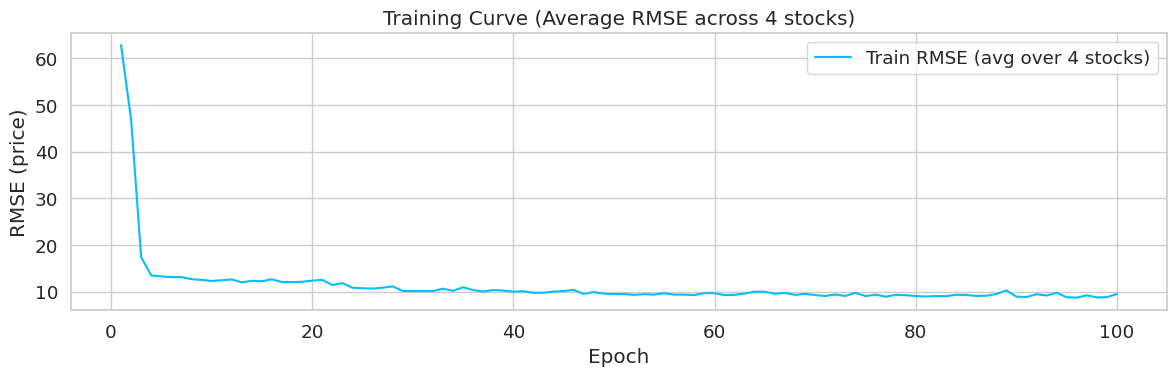

In [48]:
x = np.linspace(1, num_epochs, num_epochs)
plt.figure(figsize=(12, 4))
plt.plot(x, train_rmse_price_hist, label='Train RMSE (avg over 4 stocks)')
plt.xlabel('Epoch')
plt.ylabel('RMSE (price)')
plt.legend()
plt.title('Training Curve (Average RMSE across 4 stocks)')
plt.tight_layout()
plt.show()

## 03 Forecasting and evaluate

In [46]:
# num_forecast_steps = 14
# sequence_to_plot = X_test.squeeze().cpu().numpy()
# historical_data = sequence_to_plot[-1]

# forecasted_values = []
# with torch.no_grad():
#     for _ in range(num_forecast_steps):
#         historical_data_tensor = torch.as_tensor(historical_data).view(1, -1, 1).float().to(device)
#         predicted_value = model(historical_data_tensor).cpu().numpy()[0, 0]
#         forecasted_values.append(predicted_value)
#         historical_data = np.roll(historical_data, shift=-1)
#         historical_data[-1] = predicted_value

# last_date = X_test.index[-1]
# future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=30)

# plt.rcParams['figure.figsize'] = [14, 4]
# plt.plot(X_test.index[-100:], X_test.Open[-100:], label="test_data", color="b")
# plt.plot(X_test.index[-30:], X_test.Open[-30:], label='actual values', color='green')
# plt.plot(X_test.index[-1:].append(future_dates), np.concatenate([X_test.Open[-1:], scaler.inverse_transform(np.array(forecasted_values).reshape(-1, 1)).flatten()]), label='forecasted values', color='red')

# plt.xlabel('Time Step')
# plt.ylabel('Value')
# plt.legend()
# plt.title('Time Series Forecasting')
# plt.grid(True)
# plt.show()

# # Evaluate the model and calculate RMSE and R² score
# model.eval()
# with torch.no_grad():
#     test_predictions = []
#     for batch_X_test in X_test:
#         batch_X_test = batch_X_test.to(device).unsqueeze(0)  # Add batch dimension
#         test_predictions.append(model(batch_X_test).cpu().numpy().flatten()[0])

# test_predictions = np.array(test_predictions)

# # Calculate RMSE and R² score
# rmse = np.sqrt(mean_squared_error(y_test.cpu().numpy(), test_predictions))
# r2 = r2_score(y_test.cpu().numpy(), test_predictions)

# print(f'RMSE: {rmse:.4f}')
# print(f'R² Score: {r2:.4f}')

Test metrics by stock:
Stock 2330 - RMSE: 831.3779, R²: -10.4067
Stock 2337 - RMSE: 31.8086, R²: 0.2923
Stock 2344 - RMSE: 40.9866, R²: -0.4012
Stock 2408 - RMSE: 92.4261, R²: -0.3249
Average RMSE (4 stocks): 249.1498
Average R² (4 stocks): -2.7101


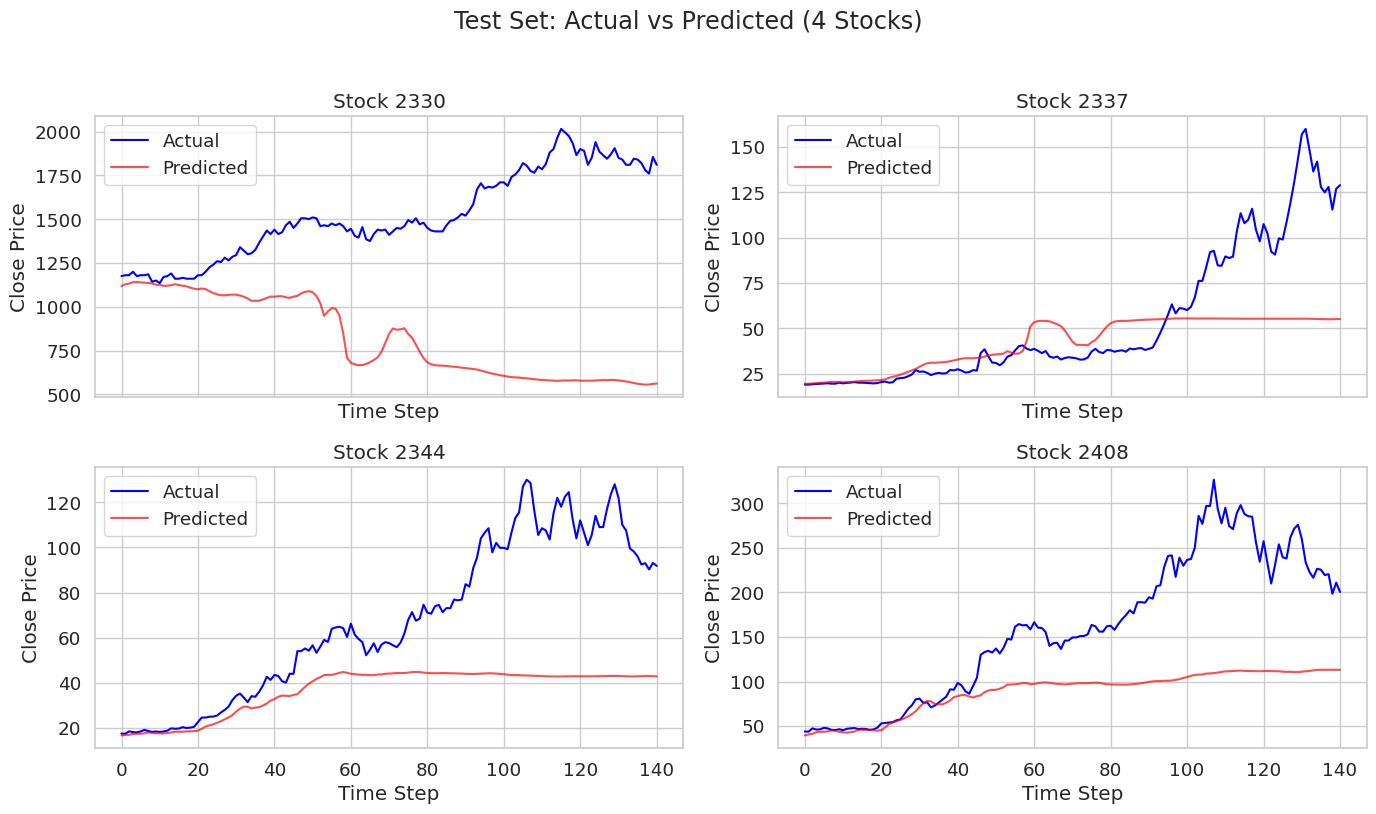

In [49]:
# Evaluate on test set: per-stock RMSE and R²
model.eval()
with torch.no_grad():
    test_predictions_scaled = []
    test_targets_scaled = []
    for batch_X_test, batch_y_test in test_loader:
        batch_X_test = batch_X_test.to(device)
        pred = model(batch_X_test).cpu().numpy()
        test_predictions_scaled.append(pred)
        test_targets_scaled.append(batch_y_test.numpy())

test_predictions_scaled = np.concatenate(test_predictions_scaled, axis=0)
test_targets_scaled = np.concatenate(test_targets_scaled, axis=0)

# Inverse transform to original price scale
test_pred_inv = y_scaler.inverse_transform(test_predictions_scaled)
test_true_inv = y_scaler.inverse_transform(test_targets_scaled)

# Metrics by stock
rmse_by_stock = np.sqrt(np.mean((test_pred_inv - test_true_inv) ** 2, axis=0))
r2_by_stock = [
    r2_score(test_true_inv[:, i], test_pred_inv[:, i])
    for i in range(test_true_inv.shape[1])
]

print("Test metrics by stock:")
for i, code in enumerate(stock_codes):
    print(f"Stock {code} - RMSE: {rmse_by_stock[i]:.4f}, R²: {r2_by_stock[i]:.4f}")

print(f"Average RMSE (4 stocks): {rmse_by_stock.mean():.4f}")
print(f"Average R² (4 stocks): {np.mean(r2_by_stock):.4f}")

# Plot actual vs predicted for each stock
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, code in enumerate(stock_codes):
    axes[i].plot(test_true_inv[:, i], label='Actual', color='blue')
    axes[i].plot(test_pred_inv[:, i], label='Predicted', color='red', alpha=0.7)
    axes[i].set_title(f'Stock {code}')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Close Price')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle('Test Set: Actual vs Predicted (4 Stocks)', y=1.02)
plt.tight_layout()
plt.show()

Train metrics by stock:
Stock 2330 - RMSE: 33.4046, R²: 0.9770
Stock 2337 - RMSE: 1.1039, R²: 0.9751
Stock 2344 - RMSE: 0.8514, R²: 0.9814
Stock 2408 - RMSE: 2.6643, R²: 0.9667
Average RMSE (4 stocks): 9.5061
Average R² (4 stocks): 0.9750


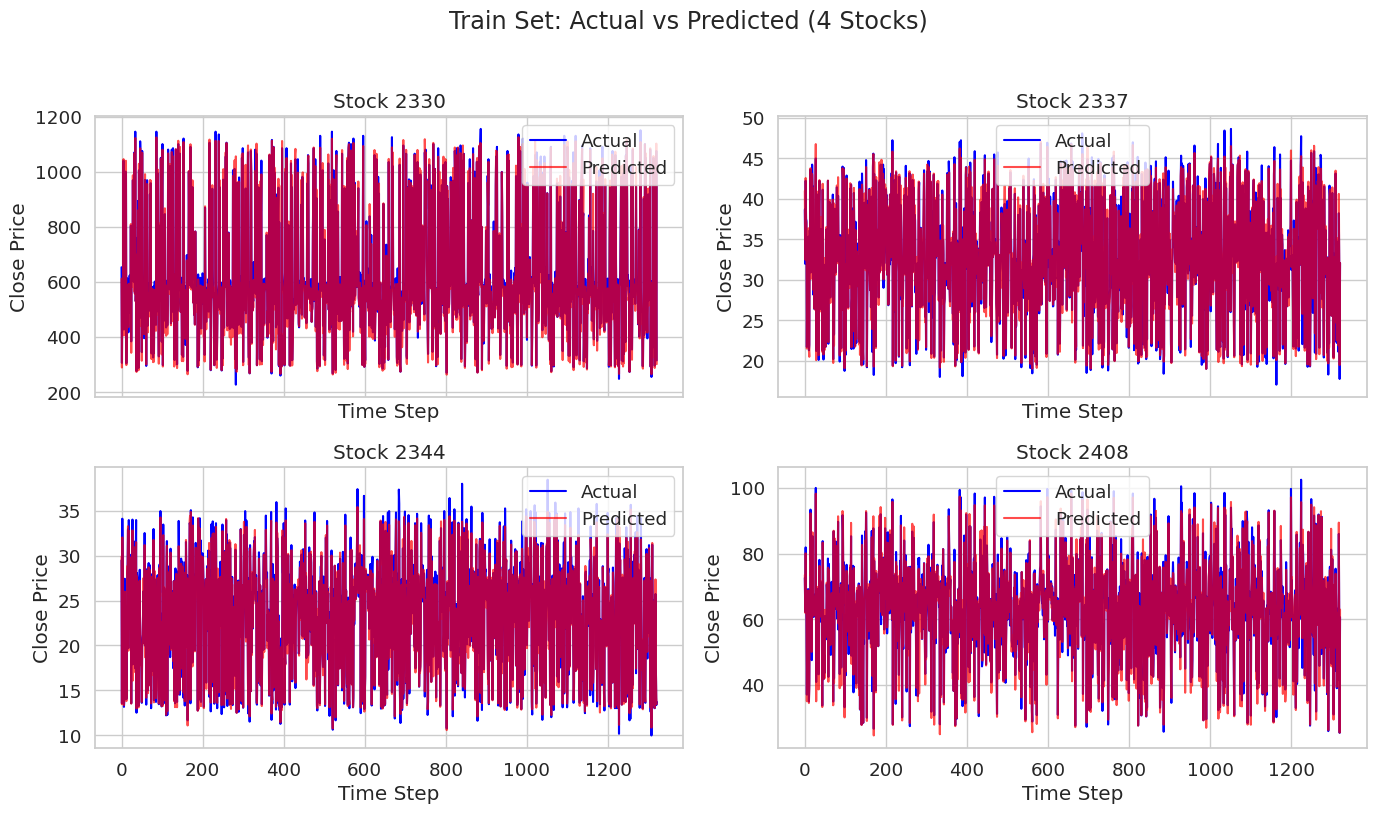

In [50]:
# Evaluate on test set: per-stock RMSE and R²
model.eval()
with torch.no_grad():
    train_predictions_scaled = []
    train_targets_scaled = []
    for batch_X_train, batch_y_train in train_loader:
        batch_X_train = batch_X_train.to(device)
        pred = model(batch_X_train).cpu().numpy()
        train_predictions_scaled.append(pred)
        train_targets_scaled.append(batch_y_train.numpy())

train_predictions_scaled = np.concatenate(train_predictions_scaled, axis=0)
train_targets_scaled = np.concatenate(train_targets_scaled, axis=0)

# Inverse transform to original price scale
train_pred_inv = y_scaler.inverse_transform(train_predictions_scaled)
train_true_inv = y_scaler.inverse_transform(train_targets_scaled)

# Metrics by stock
rmse_by_stock = np.sqrt(np.mean((train_pred_inv - train_true_inv) ** 2, axis=0))
r2_by_stock = [
    r2_score(train_true_inv[:, i], train_pred_inv[:, i])
    for i in range(train_true_inv.shape[1])
]

print("Train metrics by stock:")
for i, code in enumerate(stock_codes):
    print(f"Stock {code} - RMSE: {rmse_by_stock[i]:.4f}, R²: {r2_by_stock[i]:.4f}")

print(f"Average RMSE (4 stocks): {rmse_by_stock.mean():.4f}")
print(f"Average R² (4 stocks): {np.mean(r2_by_stock):.4f}")

# Plot actual vs predicted for each stock
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, code in enumerate(stock_codes):
    axes[i].plot(train_true_inv[:, i], label='Actual', color='blue')
    axes[i].plot(train_pred_inv[:, i], label='Predicted', color='red', alpha=0.7)
    axes[i].set_title(f'Stock {code}')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Close Price')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle('Train Set: Actual vs Predicted (4 Stocks)', y=1.02)
plt.tight_layout()
plt.show()

Note: 目前流程改為 Train / Test = 9 : 1，避免將資料再切出 Validation 造成可訓練樣本不足。若後續要做模型選參，建議使用 rolling-window backtesting 取代固定 Validation 切分。

## END